In [ ]:
# Source data: https://iea-pvps.org/wp-content/uploads/2025/09/NSR-Switzerland-2024.pdf, p. 14

In [2]:
import pandas as pd

pv_costs = pd.read_csv("pv_costs.csv")
pv_costs.head()

,Year,Lowest,Highest,Typical
0,2005,4.6,3.6,4.75
1,2006,NaN,NaN,NaN
2,2007,NaN,NaN,NaN
3,2008,NaN,NaN,NaN
4,2009,NaN,NaN,NaN


<Axes: xlabel='Year'>

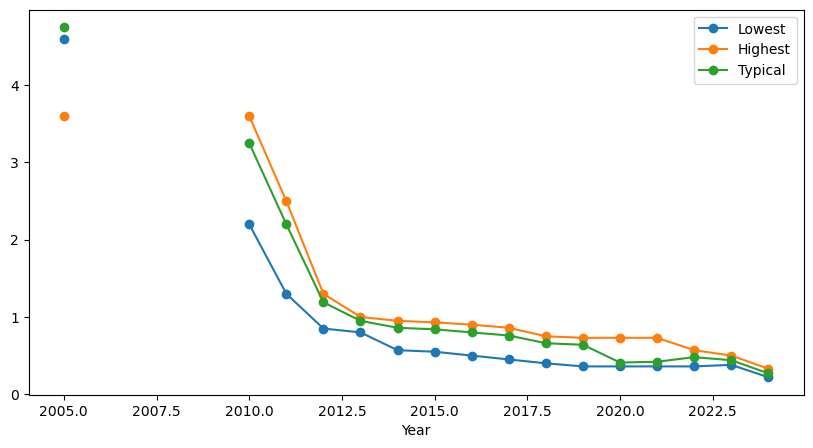

In [3]:
pv_costs.plot(x="Year", y=["Lowest", "Highest", "Typical"], figsize=(10, 5), marker="o")

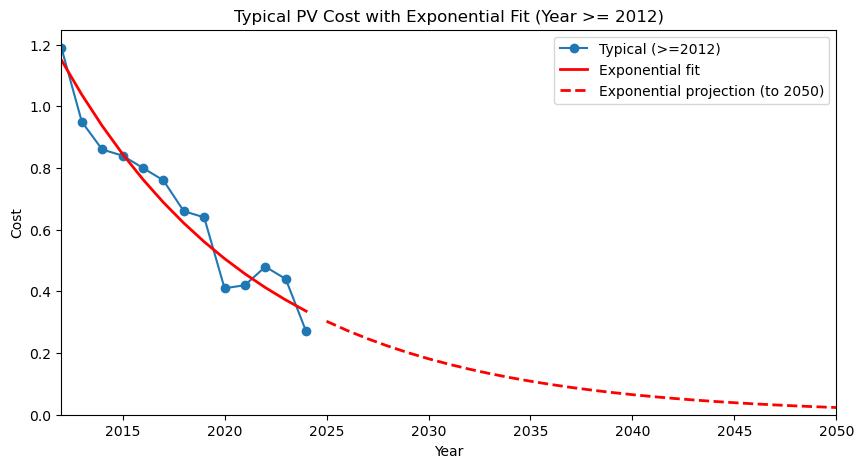

Fitted model (Year >= 2012): Typical ≈ 1.1499 * exp(-0.1026 * (Year - 2012))


In [6]:
import numpy as np
import matplotlib.pyplot as plt

# Keep only years > 2012 with non-null Typical values
fit_df = pv_costs[(pv_costs["Year"] >= 2012) & (pv_costs["Typical"].notna())].copy()

x = fit_df["Year"].to_numpy()
y = fit_df["Typical"].to_numpy()

# Fit y = a * exp(b * (x - x0)) via log transform
x0 = x.min()
b, log_a = np.polyfit(x - x0, np.log(y), 1)
a = np.exp(log_a)

# Add fitted values
fit_df["Typical_exp_fit"] = a * np.exp(b * (x - x0))

# Plot only years > 2012
plot_df = pv_costs[pv_costs["Year"] >= 2012]
ax = plot_df.plot(x="Year", y="Typical", figsize=(10, 5), marker="o", label="Typical (>=2012)")
fit_df.plot(x="Year", y="Typical_exp_fit", ax=ax, color="red", linewidth=2, label="Exponential fit")
ax.set_title("Typical PV Cost with Exponential Fit (Year >= 2012)")
ax.set_ylabel("Cost")
# Extend exponential curve through 2050
future_years = np.arange(fit_df["Year"].max() + 1, 2051)
future_fit = a * np.exp(b * (future_years - x0))

ax.plot(
    future_years,
    future_fit,
    color="red",
    linestyle="--",
    linewidth=2,
    label="Exponential projection (to 2050)"
)

ax.set_xlim(plot_df["Year"].min(), 2050)
ax.set_ylim(bottom=0)
ax.legend()
plt.show()

print(f"Fitted model (Year >= 2012): Typical ≈ {a:.4f} * exp({b:.4f} * (Year - {x0}))")